# Verified LiTS Loader and 16-Slice Overfit Gate

This is the controlled next step after the corrected LiTS v2 build passed its
dataset and spatial-review gates. It validates the real manifest-driven loader,
keeps the held-out test images locked, and runs a small training-only overfit
test before any full baseline training.

**Decision rule:** proceed to full baseline integration only when every loader
check passes and the 16-slice hard micro tumor Dice reaches **0.80 or higher**.

This is a pipeline sanity check, not a scientific model result. The overfit
subset is intentionally tiny, tumor-positive, and drawn only from the training
volumes.

## Goal

Run this notebook top-to-bottom with the project `.venv` kernel. It will:

1. verify the frozen manifest and split hashes;
2. confirm counts, uniqueness, approval status, and split isolation;
3. prove that test access is blocked by default;
4. load real training and validation examples through the strict project loader;
5. compare loaded mask pixels with the manifest;
6. visualize split balance, tumor sizes, transforms, and selected examples;
7. train MobileNetV2-U-Net on 16 training slices without augmentation;
8. save learning curves, predictions, CSV/JSON evidence, and a final gate result.

The notebook does **not** alter the dataset, promote a build, tune a validation
threshold, or evaluate the test split.

## Setup

Select the Python kernel at:

`D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\.venv\Scripts\python.exe`

The default settings run the overfit test. Set `RUN_OVERFIT = False` only when
you want a loader/data audit without training. If the GPU is hot, interrupt the
cell; the notebook saves an interruption checkpoint that can be resumed.

In [1]:
from __future__ import annotations

from pathlib import Path
from IPython.display import display
import hashlib
import json
import os
import platform
import random
import subprocess
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
import torch
from torch.utils.data import DataLoader

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path(r"D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver")
DATASET_ROOT = Path(
    r"D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\02_staging"
    r"\build_corrected_20260713_214847_v2"
)
MANIFEST_PATH = DATASET_ROOT / "manifests" / "slice_manifest.csv"
READINESS_PATH = DATASET_ROOT / "dataset_readiness.json"
VERSION_PATH = DATASET_ROOT / "dataset_version.json"
SPLIT_HASH_PATH = DATASET_ROOT / "splits" / "split_hashes.json"
OUTPUT_DIR = PROJECT_ROOT / "Practice" / "verified_loader_overfit_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

SEED = 42
RUN_OVERFIT = True
RESUME_IF_AVAILABLE = True
OVERFIT_SLICES = 16
MAX_EPOCHS = 150
BATCH_SIZE = 4
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
GATE_DICE = 0.80
PREDICTION_THRESHOLD = 0.50
MAX_GPU_TEMP_C = 87
USE_MIXED_PRECISION = True
USE_PRETRAINED_ENCODER = False  # avoids downloads; this gate tests the pipeline

EXPECTED = {
    "manifest_sha256": "575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889",
    "volumes": 131,
    "slices": 58638,
    "organ_positive_slices": 19156,
    "tumor_positive_slices": 7169,
    "organ_pixels": 87806713,
    "tumor_pixels": 4615891,
    "split_slices": {"train": 40667, "val": 10685, "test": 7286},
    "split_volumes": {"train": 104, "val": 13, "test": 14},
    "identity_volumes": 84,
    "rot180_volumes": 47,
}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Python: {sys.version.split()[0]} | OS: {platform.platform()}")
print(f"PyTorch: {torch.__version__} | CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Dataset: {DATASET_ROOT}")
print(f"Outputs: {OUTPUT_DIR}")

Python: 3.11.15 | OS: Windows-10-10.0.26200-SP0
PyTorch: 2.6.0+cu124 | CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
Dataset: D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\02_staging\build_corrected_20260713_214847_v2
Outputs: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\Practice\verified_loader_overfit_outputs


## Steps

### 1. Verify build identity and frozen hashes

In [2]:
def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while chunk := handle.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()


required_files = [MANIFEST_PATH, READINESS_PATH, VERSION_PATH, SPLIT_HASH_PATH]
missing_required = [str(path) for path in required_files if not path.is_file()]
assert not missing_required, f"Required dataset files are missing: {missing_required}"

readiness = json.loads(READINESS_PATH.read_text(encoding="utf-8"))
version = json.loads(VERSION_PATH.read_text(encoding="utf-8"))
recorded_split_hashes = json.loads(SPLIT_HASH_PATH.read_text(encoding="utf-8"))

assert readiness["status"] == "verified_eda_ready"
assert readiness["automatic_gates_pass"] is True
assert readiness["strict_validation_failures"] == 0
assert readiness["spatial_review_approved_volumes"] == 131
assert readiness["training_ready"] is False
assert version["build_id"] == DATASET_ROOT.name

observed_manifest_hash = sha256_file(MANIFEST_PATH)
assert observed_manifest_hash == EXPECTED["manifest_sha256"]
assert observed_manifest_hash == readiness["manifest_hash"]
assert observed_manifest_hash == version["manifest_hash"]

observed_split_hashes = {}
for filename, expected_hash in recorded_split_hashes.items():
    split_file = DATASET_ROOT / "splits" / filename
    assert split_file.is_file(), f"Missing split file: {split_file}"
    observed_split_hashes[filename] = sha256_file(split_file)
    assert observed_split_hashes[filename] == expected_hash, filename

hash_table = pd.DataFrame(
    [
        {"artifact": "slice_manifest.csv", "sha256": observed_manifest_hash, "match": True},
        *[
            {
                "artifact": filename,
                "sha256": observed_split_hashes[filename],
                "match": observed_split_hashes[filename] == expected_hash,
            }
            for filename, expected_hash in recorded_split_hashes.items()
        ],
    ]
)
display(hash_table)
print("PASS: build identity and all frozen hashes match.")

,artifact,sha256,match
0,slice_manifest.csv,575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63...,True
1,train_slices.csv,6b0e2753dbbf780383fdf25f4421f32c496752265d83a3...,True
2,train_volumes.txt,6183e84acb5a30fd04a38875f54c6a02b4f64f588725f2...,True
3,val_slices.csv,4b3d6abd06823239dda131add2eb407d48078fcd17b931...,True
4,val_volumes.txt,a28fea675229371093748adb90e9c1d23dd2a5699fd6f8...,True
5,test_slices.csv,6034134006793c9f5a1392aec51c3e44eb47b54d6ab2e7...,True
6,test_volumes.txt,830f8ded37afeb01347c5f222d91d253ac11cad8bc9621...,True


PASS: build identity and all frozen hashes match.


### 2. Audit manifest schema, counts, approvals, and split isolation

In [3]:
manifest = pd.read_csv(MANIFEST_PATH)

required_columns = {
    "sample_id", "volume_id", "slice_index", "image_path",
    "organ_mask_path", "tumor_mask_path", "transform_applied",
    "image_width", "image_height", "organ_pixels", "tumor_pixels",
    "automatic_integrity_pass", "verification_status", "exclusion_reason",
    "build_id", "preprocessing_profile", "mask_operation_order", "split",
    "manual_spatial_status",
}
missing_columns = required_columns - set(manifest.columns)
assert not missing_columns, f"Missing manifest columns: {sorted(missing_columns)}"

assert len(manifest) == EXPECTED["slices"]
assert manifest["sample_id"].is_unique
assert manifest[["volume_id", "slice_index"]].duplicated().sum() == 0
assert manifest["volume_id"].nunique() == EXPECTED["volumes"]
assert set(manifest["split"].unique()) == {"train", "val", "test"}
assert manifest["image_width"].eq(256).all()
assert manifest["image_height"].eq(256).all()
assert manifest["verification_status"].eq("verified").all()
assert manifest["automatic_integrity_pass"].astype(str).str.lower().eq("true").all()
assert manifest["manual_spatial_status"].eq("approved").all()
assert manifest["exclusion_reason"].fillna("").eq("").all()
assert manifest["build_id"].eq(DATASET_ROOT.name).all()
assert manifest["mask_operation_order"].eq(
    "derive_resize_nearest_then_transform_256"
).all()

observed_counts = {
    "volumes": int(manifest["volume_id"].nunique()),
    "slices": int(len(manifest)),
    "organ_positive_slices": int((manifest["organ_pixels"] > 0).sum()),
    "tumor_positive_slices": int((manifest["tumor_pixels"] > 0).sum()),
    "organ_pixels": int(manifest["organ_pixels"].sum()),
    "tumor_pixels": int(manifest["tumor_pixels"].sum()),
    "identity_volumes": int(
        manifest.loc[manifest["transform_applied"].eq("identity"), "volume_id"].nunique()
    ),
    "rot180_volumes": int(
        manifest.loc[manifest["transform_applied"].eq("rot180"), "volume_id"].nunique()
    ),
}
for key, expected_value in EXPECTED.items():
    if key in observed_counts:
        assert observed_counts[key] == expected_value, (key, observed_counts[key], expected_value)

split_summary = (
    manifest.groupby("split")
    .agg(
        volumes=("volume_id", "nunique"),
        slices=("sample_id", "size"),
        organ_positive_slices=("organ_pixels", lambda values: int((values > 0).sum())),
        tumor_positive_slices=("tumor_pixels", lambda values: int((values > 0).sum())),
        organ_pixels=("organ_pixels", "sum"),
        tumor_pixels=("tumor_pixels", "sum"),
    )
    .reindex(["train", "val", "test"])
    .reset_index()
)
for row in split_summary.itertuples(index=False):
    assert row.slices == EXPECTED["split_slices"][row.split]
    assert row.volumes == EXPECTED["split_volumes"][row.split]

volume_sets = {
    split: set(manifest.loc[manifest["split"].eq(split), "volume_id"].unique())
    for split in ("train", "val", "test")
}
assert volume_sets["train"].isdisjoint(volume_sets["val"])
assert volume_sets["train"].isdisjoint(volume_sets["test"])
assert volume_sets["val"].isdisjoint(volume_sets["test"])
assert volume_sets["train"] == set(range(0, 104))
assert volume_sets["val"] == set(range(104, 117))
assert volume_sets["test"] == set(range(117, 131))

display(pd.DataFrame([observed_counts]).T.rename(columns={0: "observed"}))
display(split_summary)
print("PASS: manifest counts, approvals, geometry, and volume-wise split isolation match.")

,observed
volumes,131
slices,58638
organ_positive_slices,19156
tumor_positive_slices,7169
organ_pixels,87806713
tumor_pixels,4615891
identity_volumes,84
rot180_volumes,47


,split,volumes,slices,organ_positive_slices,tumor_positive_slices,organ_pixels,tumor_pixels
0,train,104,40667,14151,4930,63862581,2589463
1,val,13,10685,2651,1042,11675392,659487
2,test,14,7286,2354,1197,12268740,1366941


PASS: manifest counts, approvals, geometry, and volume-wise split isolation match.


### 3. Visualize dataset structure before loading images

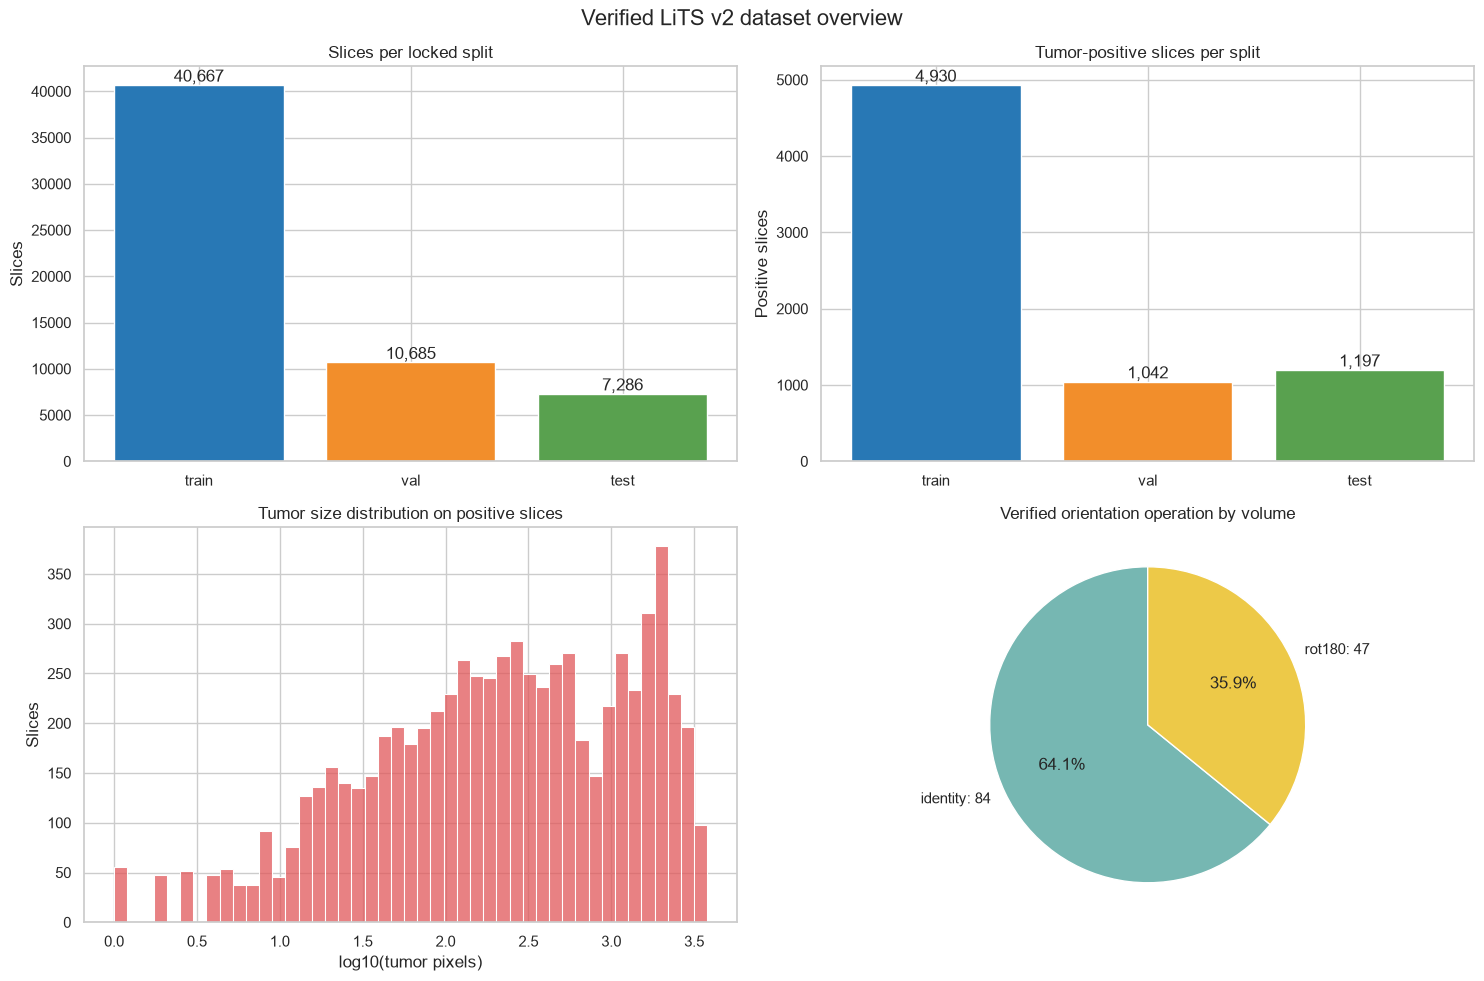

Saved: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\Practice\verified_loader_overfit_outputs\dataset_gate_overview.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
split_colors = ["#2878B5", "#F28E2B", "#59A14F"]

axes[0, 0].bar(
    split_summary["split"], split_summary["slices"], color=split_colors
)
axes[0, 0].set_title("Slices per locked split")
axes[0, 0].set_ylabel("Slices")
for index, value in enumerate(split_summary["slices"]):
    axes[0, 0].text(index, value, f"{value:,}", ha="center", va="bottom")

axes[0, 1].bar(
    split_summary["split"], split_summary["tumor_positive_slices"], color=split_colors
)
axes[0, 1].set_title("Tumor-positive slices per split")
axes[0, 1].set_ylabel("Positive slices")
for index, value in enumerate(split_summary["tumor_positive_slices"]):
    axes[0, 1].text(index, value, f"{value:,}", ha="center", va="bottom")

positive_pixels = manifest.loc[manifest["tumor_pixels"] > 0, "tumor_pixels"]
sns.histplot(np.log10(positive_pixels), bins=45, ax=axes[1, 0], color="#E15759")
axes[1, 0].set_title("Tumor size distribution on positive slices")
axes[1, 0].set_xlabel("log10(tumor pixels)")
axes[1, 0].set_ylabel("Slices")

transform_counts = (
    manifest[["volume_id", "transform_applied"]]
    .drop_duplicates()["transform_applied"]
    .value_counts()
    .reindex(["identity", "rot180"])
)
axes[1, 1].pie(
    transform_counts,
    labels=[f"{name}: {count}" for name, count in transform_counts.items()],
    autopct="%1.1f%%",
    colors=["#76B7B2", "#EDC948"],
    startangle=90,
)
axes[1, 1].set_title("Verified orientation operation by volume")

fig.suptitle("Verified LiTS v2 dataset overview", fontsize=16)
fig.tight_layout()
overview_path = OUTPUT_DIR / "dataset_gate_overview.png"
fig.savefig(overview_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {overview_path}")

### 4. Validate the strict manifest loader and test lock

The project loader is allowed to open only `train` and `val` here. The explicit
test-lock check must raise `PermissionError`; that is a successful safety test.

In [5]:
from src.framework.data.manifest_dataset import VerifiedManifestDataset

try:
    VerifiedManifestDataset(
        MANIFEST_PATH,
        split="test",
        root_dir=DATASET_ROOT,
    )
except PermissionError as exc:
    print(f"PASS: test split is locked by default: {exc}")
else:
    raise AssertionError("Test split unexpectedly opened without explicit authorization")

train_dataset = VerifiedManifestDataset(
    MANIFEST_PATH,
    split="train",
    root_dir=DATASET_ROOT,
    target="tumor",
    validate_paths=True,
)
val_dataset = VerifiedManifestDataset(
    MANIFEST_PATH,
    split="val",
    root_dir=DATASET_ROOT,
    target="tumor",
    validate_paths=True,
)

assert len(train_dataset) == EXPECTED["split_slices"]["train"]
assert len(val_dataset) == EXPECTED["split_slices"]["val"]
assert all(row["split"] == "train" for row in train_dataset.rows)
assert all(row["split"] == "val" for row in val_dataset.rows)
assert set(train_dataset.sample_ids).isdisjoint(val_dataset.sample_ids)

print(f"Train loader rows: {len(train_dataset):,}")
print(f"Validation loader rows: {len(val_dataset):,}")
print("PASS: strict train/validation datasets constructed from verified rows only.")

PASS: test split is locked by default: Test data access is locked. Pass allow_test=True only for the one-time held-out evaluation after model decisions are frozen.
Train loader rows: 40,667
Validation loader rows: 10,685
PASS: strict train/validation datasets constructed from verified rows only.


### 5. Run loader pixel-parity checks and inspect representative slices

In [6]:
def pick_audit_ids(frame: pd.DataFrame, count_each: int = 8) -> list[str]:
    empty = frame.loc[frame["tumor_pixels"].eq(0)].sample(
        n=count_each, random_state=SEED
    )
    positive = frame.loc[frame["tumor_pixels"].gt(0)].copy()
    positive["size_bin"] = pd.qcut(
        positive["tumor_pixels"], q=4, labels=False, duplicates="drop"
    )
    selected_positive = (
        positive.groupby("size_bin", group_keys=False)
        .apply(lambda group: group.sample(n=min(2, len(group)), random_state=SEED))
        .head(count_each)
    )
    return pd.concat([empty, selected_positive])["sample_id"].tolist()


audit_ids = pick_audit_ids(manifest.loc[manifest["split"].eq("train")])
audit_dataset = VerifiedManifestDataset(
    MANIFEST_PATH,
    split="train",
    root_dir=DATASET_ROOT,
    target="tumor",
    sample_ids=audit_ids,
)

audit_records = []
for item in audit_dataset:
    image = item["image"].numpy()
    mask = item["mask"].numpy()
    assert image.shape == (1, 256, 256)
    assert mask.shape == (1, 256, 256)
    assert image.dtype == np.float32
    assert mask.dtype == np.float32
    assert 0.0 <= float(image.min()) <= float(image.max()) <= 1.0
    assert set(np.unique(mask)).issubset({0.0, 1.0})
    audit_records.append(
        {
            "sample_id": item["sample_id"],
            "volume_id": int(item["volume_id"]),
            "slice_index": int(item["slice_index"]),
            "loaded_tumor_pixels": int(mask.sum()),
            "manifest_tumor_pixels": int(item["tumor_pixels"]),
            "pixel_count_match": int(mask.sum()) == int(item["tumor_pixels"]),
        }
    )

audit_table = pd.DataFrame(audit_records)
assert audit_table["pixel_count_match"].all()
audit_table.to_csv(OUTPUT_DIR / "loader_pixel_parity_audit.csv", index=False)
display(audit_table)

batch_loader = DataLoader(
    audit_dataset, batch_size=4, shuffle=False, num_workers=0
)
batch = next(iter(batch_loader))
assert batch["image"].shape == (4, 1, 256, 256)
assert batch["mask"].shape == (4, 1, 256, 256)
assert set(batch["split"]) == {"train"}
print("PASS: image range, binary masks, shape, batch collation, and pixel parity.")

,sample_id,volume_id,slice_index,loaded_tumor_pixels,manifest_tumor_pixels,pixel_count_match
0,v095_s0080,95,80,0,0,True
1,v005_s0469,5,469,0,0,True
2,v025_s0447,25,447,0,0,True
3,v092_s0541,92,541,0,0,True
4,v017_s0298,17,298,0,0,True
5,v019_s0471,19,471,0,0,True
6,v014_s0400,14,400,0,0,True
7,v057_s0003,57,3,0,0,True
8,v084_s0632,84,632,18,18,True
9,v049_s0158,49,158,41,41,True


PASS: image range, binary masks, shape, batch collation, and pixel parity.


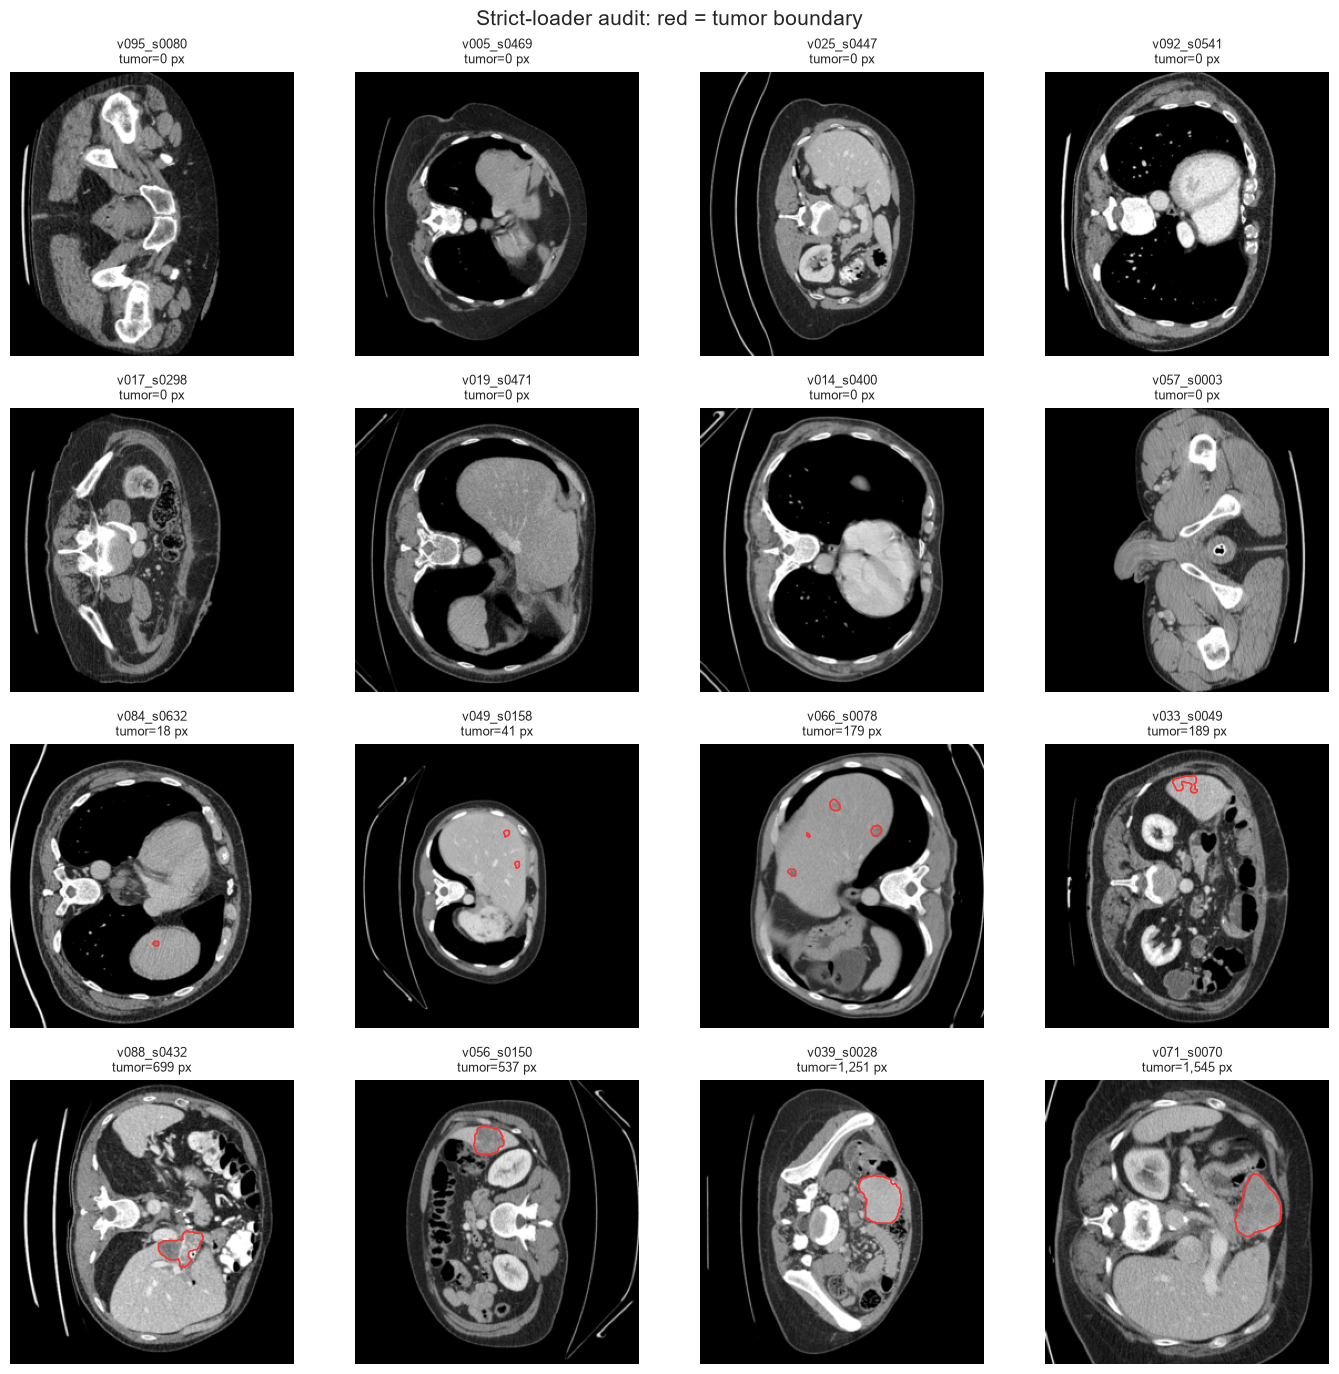

Saved: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\Practice\verified_loader_overfit_outputs\loader_audit_overlays.png


In [7]:
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for axis, item in zip(axes.ravel(), audit_dataset):
    image = item["image"][0].numpy()
    mask = item["mask"][0].numpy()
    axis.imshow(image, cmap="gray", vmin=0, vmax=1)
    if mask.any():
        axis.contour(mask, levels=[0.5], colors="#FF3030", linewidths=1.2)
    axis.set_title(
        f"{item['sample_id']}\n"
        f"tumor={int(item['tumor_pixels']):,} px",
        fontsize=9,
    )
    axis.axis("off")
fig.suptitle("Strict-loader audit: red = tumor boundary", fontsize=15)
fig.tight_layout()
audit_figure_path = OUTPUT_DIR / "loader_audit_overlays.png"
fig.savefig(audit_figure_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {audit_figure_path}")

### 6. Select the deterministic 16-slice training subset

Selection spans tumor-size quartiles and favors different volumes. This reduces
the chance that the check passes by memorizing nearly identical neighboring
slices from one patient. No validation or test row is eligible.

In [8]:
def select_overfit_rows(
    frame: pd.DataFrame, n_slices: int = 16, seed: int = 42
) -> pd.DataFrame:
    candidates = frame.loc[
        frame["split"].eq("train") & frame["tumor_pixels"].gt(0)
    ].copy()
    candidates["size_quartile"] = pd.qcut(
        candidates["tumor_pixels"], q=4, labels=False, duplicates="drop"
    )

    selected_indices = []
    used_volumes = set()
    target_per_bin = max(1, n_slices // candidates["size_quartile"].nunique())
    for quartile in sorted(candidates["size_quartile"].dropna().unique()):
        group = candidates.loc[candidates["size_quartile"].eq(quartile)].sample(
            frac=1, random_state=seed + int(quartile)
        )
        chosen = 0
        for index, row in group.iterrows():
            if int(row["volume_id"]) in used_volumes:
                continue
            selected_indices.append(index)
            used_volumes.add(int(row["volume_id"]))
            chosen += 1
            if chosen == target_per_bin or len(selected_indices) == n_slices:
                break

    if len(selected_indices) < n_slices:
        remainder = candidates.drop(index=selected_indices).sample(
            frac=1, random_state=seed + 100
        )
        for index, row in remainder.iterrows():
            selected_indices.append(index)
            if len(selected_indices) == n_slices:
                break

    selected = candidates.loc[selected_indices].copy()
    selected = selected.sort_values(
        ["size_quartile", "tumor_pixels", "volume_id", "slice_index"]
    ).reset_index(drop=True)
    if len(selected) != n_slices:
        raise RuntimeError(f"Selected {len(selected)} rows; expected {n_slices}")
    return selected


selected_rows = select_overfit_rows(manifest, OVERFIT_SLICES, SEED)
assert selected_rows["split"].eq("train").all()
assert selected_rows["tumor_pixels"].gt(0).all()
assert selected_rows["sample_id"].is_unique
assert not set(selected_rows["sample_id"]) & set(
    manifest.loc[manifest["split"].eq("test"), "sample_id"]
)

selected_columns = [
    "sample_id", "volume_id", "slice_index", "tumor_pixels",
    "organ_pixels", "transform_applied", "size_quartile", "split",
]
selected_rows[selected_columns].to_csv(
    OUTPUT_DIR / "overfit_selected_slices.csv", index=False
)
display(selected_rows[selected_columns])
print(
    f"Selected {len(selected_rows)} tumor-positive training slices from "
    f"{selected_rows['volume_id'].nunique()} volumes."
)

,sample_id,volume_id,slice_index,tumor_pixels,organ_pixels,transform_applied,size_quartile,split
0,v084_s0632,84,632,18,2149,rot180,0,train
1,v008_s0391,8,391,40,3071,identity,0,train
2,v049_s0158,49,158,41,4768,identity,0,train
3,v037_s0092,37,92,42,7552,identity,0,train
4,v007_s0387,7,387,68,4144,identity,1,train
5,v019_s0439,19,439,157,10450,identity,1,train
6,v035_s0053,35,53,169,6944,identity,1,train
7,v068_s0132,68,132,192,8903,identity,1,train
8,v103_s0515,103,515,307,3028,rot180,2,train
9,v101_s0422,101,422,392,1759,rot180,2,train


Selected 16 tumor-positive training slices from 16 volumes.


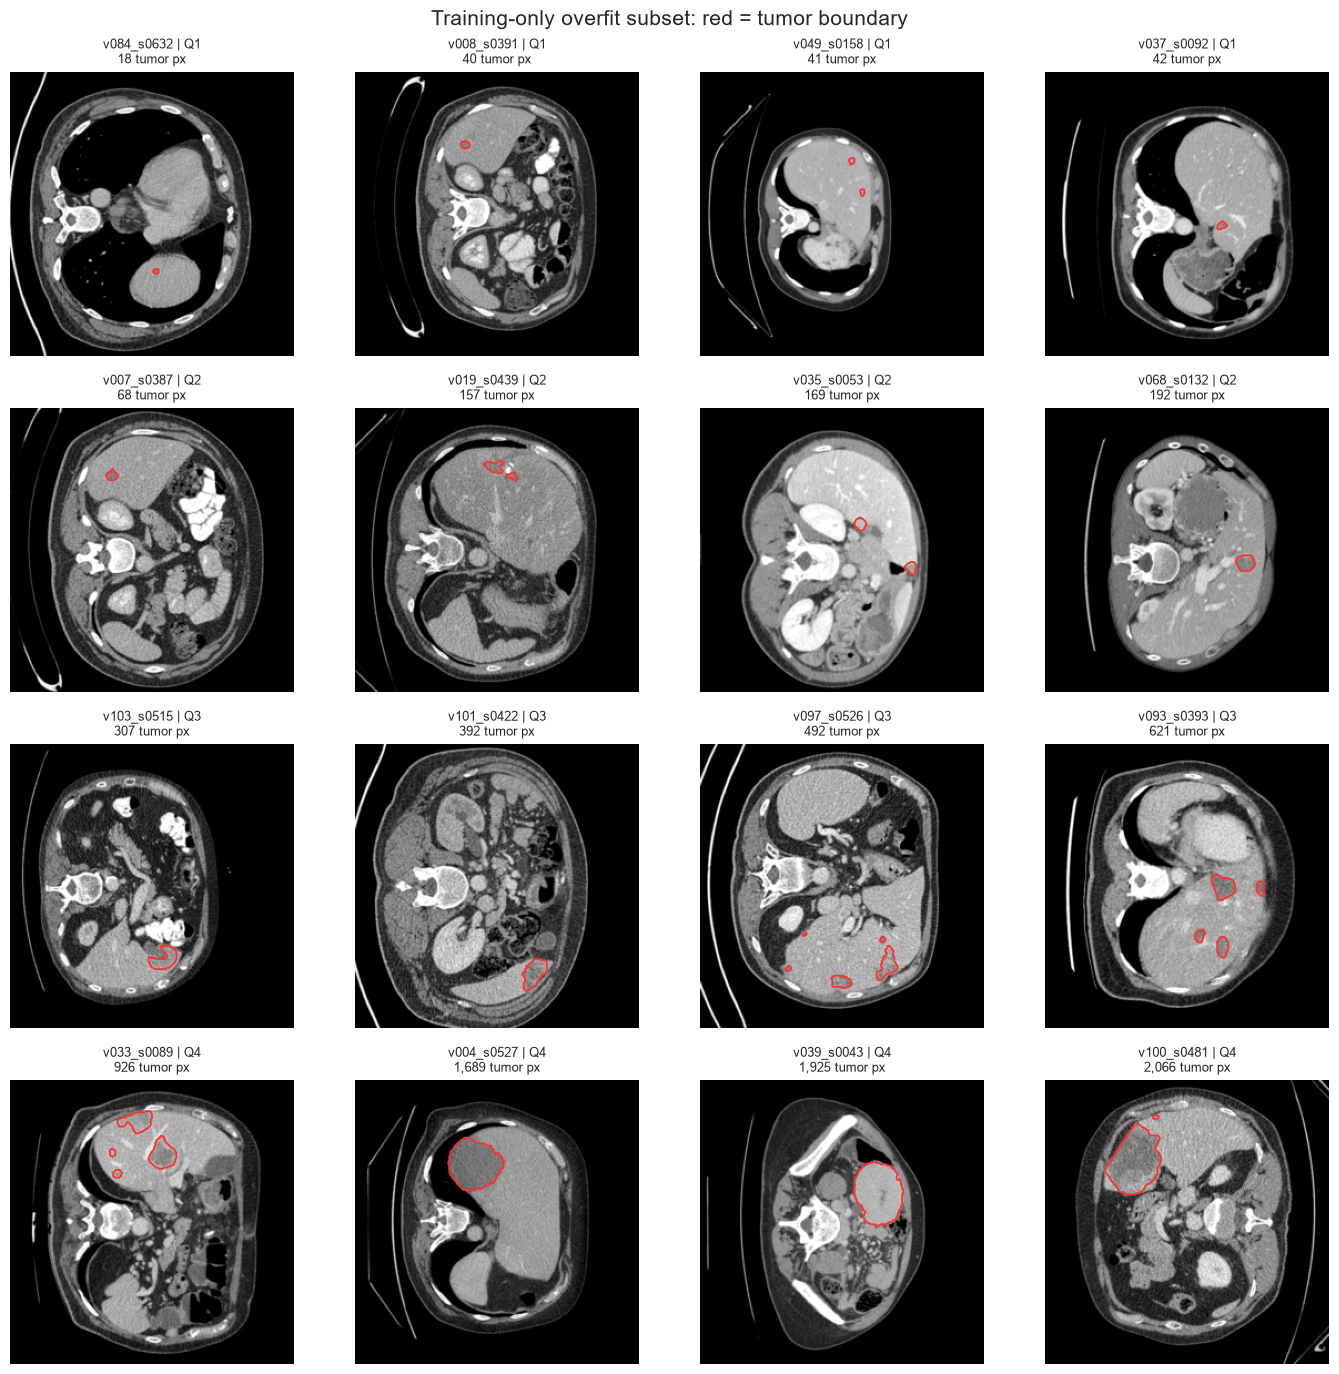

Saved: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\Practice\verified_loader_overfit_outputs\overfit_selected_slices.png


In [9]:
overfit_dataset = VerifiedManifestDataset(
    MANIFEST_PATH,
    split="train",
    root_dir=DATASET_ROOT,
    target="tumor",
    sample_ids=selected_rows["sample_id"].tolist(),
)

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for axis, item in zip(axes.ravel(), overfit_dataset):
    image = item["image"][0].numpy()
    mask = item["mask"][0].numpy()
    axis.imshow(image, cmap="gray", vmin=0, vmax=1)
    axis.contour(mask, levels=[0.5], colors="#FF3030", linewidths=1.3)
    quartile = int(
        selected_rows.loc[
            selected_rows["sample_id"].eq(item["sample_id"]), "size_quartile"
        ].iloc[0]
    )
    axis.set_title(
        f"{item['sample_id']} | Q{quartile + 1}\n"
        f"{int(item['tumor_pixels']):,} tumor px",
        fontsize=9,
    )
    axis.axis("off")
fig.suptitle("Training-only overfit subset: red = tumor boundary", fontsize=15)
fig.tight_layout()
selection_path = OUTPUT_DIR / "overfit_selected_slices.png"
fig.savefig(selection_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {selection_path}")

## Checks

### 7. Define metrics, GPU monitoring, checkpointing, and training loop

This cell only defines functions. The following cell starts training. The gate
uses hard micro Dice at threshold 0.50. Soft Dice and macro per-slice Dice are
also recorded to diagnose threshold or small-lesion effects.

In [10]:
from src.framework.losses.focal_dice import FocalDiceLoss
from src.framework.models.mobilenetv2_unet import MobileNetV2UNet


def hard_dice_components(
    logits: torch.Tensor, targets: torch.Tensor, threshold: float
) -> tuple[float, float, float]:
    predictions = torch.sigmoid(logits) >= threshold
    truth = targets >= 0.5
    intersection = (predictions & truth).sum().item()
    predicted = predictions.sum().item()
    actual = truth.sum().item()
    return float(intersection), float(predicted), float(actual)


def evaluate_overfit(model, loader, device, threshold=0.5):
    model.eval()
    total_intersection = total_predicted = total_actual = 0.0
    soft_intersection = soft_denominator = 0.0
    slice_dice = []
    rows = []
    with torch.inference_mode():
        for batch in loader:
            images = batch["image"].to(device, non_blocking=True)
            masks = batch["mask"].to(device, non_blocking=True)
            logits = model(images)
            probabilities = torch.sigmoid(logits)
            predictions = probabilities >= threshold
            truth = masks >= 0.5

            total_intersection += float((predictions & truth).sum())
            total_predicted += float(predictions.sum())
            total_actual += float(truth.sum())
            soft_intersection += float((probabilities * masks).sum())
            soft_denominator += float(probabilities.sum() + masks.sum())

            for index, sample_id in enumerate(batch["sample_id"]):
                intersection = float((predictions[index] & truth[index]).sum())
                denominator = float(predictions[index].sum() + truth[index].sum())
                dice = (2 * intersection + 1e-6) / (denominator + 1e-6)
                slice_dice.append(dice)
                rows.append(
                    {
                        "sample_id": sample_id,
                        "dice": dice,
                        "predicted_pixels": int(predictions[index].sum()),
                        "true_pixels": int(truth[index].sum()),
                        "mean_probability": float(probabilities[index].mean()),
                    }
                )

    micro_dice = (
        (2 * total_intersection + 1e-6)
        / (total_predicted + total_actual + 1e-6)
    )
    soft_dice = (2 * soft_intersection + 1e-6) / (soft_denominator + 1e-6)
    return {
        "hard_micro_dice": float(micro_dice),
        "hard_macro_slice_dice": float(np.mean(slice_dice)),
        "soft_micro_dice": float(soft_dice),
        "predicted_pixels": int(total_predicted),
        "true_pixels": int(total_actual),
        "per_slice": rows,
    }


def gpu_stats():
    if not torch.cuda.is_available():
        return {"temperature_c": np.nan, "utilization_pct": np.nan, "memory_mb": np.nan}
    command = [
        "nvidia-smi",
        "--query-gpu=temperature.gpu,utilization.gpu,memory.used",
        "--format=csv,noheader,nounits",
    ]
    try:
        result = subprocess.run(command, capture_output=True, text=True, check=True)
        values = [float(value.strip()) for value in result.stdout.splitlines()[0].split(",")]
        return {
            "temperature_c": values[0],
            "utilization_pct": values[1],
            "memory_mb": values[2],
        }
    except Exception:
        return {"temperature_c": np.nan, "utilization_pct": np.nan, "memory_mb": np.nan}


def save_checkpoint(path, model, optimizer, scaler, epoch, history, sample_ids):
    torch.save(
        {
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scaler_state": scaler.state_dict(),
            "epoch": int(epoch),
            "history": history,
            "sample_ids": list(sample_ids),
            "seed": SEED,
        },
        path,
    )


def save_progress(history, status, extra=None):
    history_frame = pd.DataFrame(history)
    history_frame.to_csv(OUTPUT_DIR / "overfit_history.csv", index=False)
    payload = {
        "status": status,
        "gate_dice": GATE_DICE,
        "threshold": PREDICTION_THRESHOLD,
        "epochs_completed": int(history_frame["epoch"].max()) if len(history_frame) else 0,
        "best_hard_micro_dice": (
            float(history_frame["hard_micro_dice"].max()) if len(history_frame) else None
        ),
        "selected_sample_ids": overfit_dataset.sample_ids,
        "test_images_accessed": False,
    }
    if extra:
        payload.update(extra)
    (OUTPUT_DIR / "overfit_status.json").write_text(
        json.dumps(payload, indent=2), encoding="utf-8"
    )
    return payload

### 8. Run or resume the 16-slice overfit gate

Expected GPU runtime is short compared with baseline training because each epoch
has only four batches. If temperature exceeds 87°C, the loop pauses after saving
`overfit_last_checkpoint.pth`. Let the GPU cool, then rerun this cell.

In [11]:
if not RUN_OVERFIT:
    training_status = save_progress([], "skipped_by_configuration")
    print("Overfit training skipped because RUN_OVERFIT=False.")
else:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    amp_enabled = bool(USE_MIXED_PRECISION and device.type == "cuda")
    data_generator = torch.Generator().manual_seed(SEED)
    overfit_loader = DataLoader(
        overfit_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=device.type == "cuda",
        generator=data_generator,
    )
    evaluation_loader = DataLoader(
        overfit_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=device.type == "cuda",
    )

    model = MobileNetV2UNet(
        in_channels=1,
        out_channels=1,
        pretrained=USE_PRETRAINED_ENCODER,
    ).to(device)
    criterion = FocalDiceLoss(
        focal_alpha=0.75,
        focal_gamma=2.0,
        focal_weight=0.5,
        dice_weight=0.5,
    )
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)

    checkpoint_path = OUTPUT_DIR / "overfit_last_checkpoint.pth"
    start_epoch = 1
    history = []
    if RESUME_IF_AVAILABLE and checkpoint_path.is_file():
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
        if checkpoint.get("sample_ids") != overfit_dataset.sample_ids:
            raise RuntimeError(
                "Existing checkpoint uses different selected slices. Delete "
                f"{checkpoint_path} to start a fresh gate run."
            )
        model.load_state_dict(checkpoint["model_state"])
        optimizer.load_state_dict(checkpoint["optimizer_state"])
        scaler.load_state_dict(checkpoint.get("scaler_state", {}))
        history = list(checkpoint.get("history", []))
        start_epoch = int(checkpoint["epoch"]) + 1
        print(f"Resuming from epoch {start_epoch}.")

    consecutive_passes = 0
    started = time.perf_counter()
    status = "running"
    try:
        for epoch in range(start_epoch, MAX_EPOCHS + 1):
            model.train()
            epoch_loss = 0.0
            for batch in overfit_loader:
                images = batch["image"].to(device, non_blocking=True)
                masks = batch["mask"].to(device, non_blocking=True)
                optimizer.zero_grad(set_to_none=True)
                with torch.cuda.amp.autocast(enabled=amp_enabled):
                    logits = model(images)
                    loss = criterion(logits, masks)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                epoch_loss += float(loss.detach()) * images.shape[0]

            metrics = evaluate_overfit(
                model, evaluation_loader, device, PREDICTION_THRESHOLD
            )
            thermal = gpu_stats()
            record = {
                "epoch": epoch,
                "loss": epoch_loss / len(overfit_dataset),
                "hard_micro_dice": metrics["hard_micro_dice"],
                "hard_macro_slice_dice": metrics["hard_macro_slice_dice"],
                "soft_micro_dice": metrics["soft_micro_dice"],
                "predicted_pixels": metrics["predicted_pixels"],
                "true_pixels": metrics["true_pixels"],
                "temperature_c": thermal["temperature_c"],
                "utilization_pct": thermal["utilization_pct"],
                "memory_mb": thermal["memory_mb"],
                "elapsed_seconds": time.perf_counter() - started,
            }
            history.append(record)
            save_checkpoint(
                checkpoint_path,
                model,
                optimizer,
                scaler,
                epoch,
                history,
                overfit_dataset.sample_ids,
            )
            save_progress(history, "running")

            if epoch == 1 or epoch % 5 == 0 or metrics["hard_micro_dice"] >= GATE_DICE:
                temperature = thermal["temperature_c"]
                temperature_text = (
                    f"{temperature:.0f}C" if np.isfinite(temperature) else "n/a"
                )
                print(
                    f"epoch={epoch:03d} loss={record['loss']:.4f} "
                    f"hard_dice={record['hard_micro_dice']:.4f} "
                    f"soft_dice={record['soft_micro_dice']:.4f} "
                    f"gpu_temp={temperature_text}"
                )

            if metrics["hard_micro_dice"] >= GATE_DICE:
                consecutive_passes += 1
            else:
                consecutive_passes = 0
            if consecutive_passes >= 2:
                status = "passed"
                print(f"PASS: hard micro Dice >= {GATE_DICE:.2f} for two epochs.")
                break

            if (
                np.isfinite(thermal["temperature_c"])
                and thermal["temperature_c"] > MAX_GPU_TEMP_C
            ):
                status = "paused_hot"
                print(
                    f"PAUSED: GPU temperature {thermal['temperature_c']:.0f}C "
                    f"exceeded {MAX_GPU_TEMP_C}C. Cool the GPU and rerun this cell."
                )
                break
        else:
            status = "failed_gate"
    except KeyboardInterrupt:
        status = "interrupted"
        save_checkpoint(
            OUTPUT_DIR / "overfit_interrupted_checkpoint.pth",
            model,
            optimizer,
            scaler,
            history[-1]["epoch"] if history else 0,
            history,
            overfit_dataset.sample_ids,
        )
        print("Interrupted safely. Checkpoint and history were saved.")
    finally:
        training_status = save_progress(
            history,
            status,
            {
                "device": str(device),
                "mixed_precision": amp_enabled,
                "pretrained_encoder": USE_PRETRAINED_ENCODER,
                "max_epochs": MAX_EPOCHS,
            },
        )
        display(pd.DataFrame([training_status]))

epoch=001 loss=0.5060 hard_dice=0.0000 soft_dice=0.0173 gpu_temp=74C
epoch=005 loss=0.4974 hard_dice=0.0314 soft_dice=0.0191 gpu_temp=75C
epoch=010 loss=0.4898 hard_dice=0.0283 soft_dice=0.0252 gpu_temp=73C
epoch=015 loss=0.4852 hard_dice=0.1512 soft_dice=0.0327 gpu_temp=76C
epoch=020 loss=0.4824 hard_dice=0.1058 soft_dice=0.0477 gpu_temp=76C
epoch=025 loss=0.4738 hard_dice=0.2886 soft_dice=0.0730 gpu_temp=80C
epoch=030 loss=0.4499 hard_dice=0.4584 soft_dice=0.1214 gpu_temp=78C
epoch=035 loss=0.4604 hard_dice=0.2097 soft_dice=0.0688 gpu_temp=81C
epoch=040 loss=0.4370 hard_dice=0.3120 soft_dice=0.0711 gpu_temp=80C
epoch=045 loss=0.4209 hard_dice=0.0876 soft_dice=0.0729 gpu_temp=83C
epoch=050 loss=0.3957 hard_dice=0.6388 soft_dice=0.1074 gpu_temp=83C
epoch=055 loss=0.4156 hard_dice=0.4222 soft_dice=0.0742 gpu_temp=83C
epoch=060 loss=0.4076 hard_dice=0.2900 soft_dice=0.0793 gpu_temp=82C
epoch=065 loss=0.3615 hard_dice=0.6835 soft_dice=0.0778 gpu_temp=82C
epoch=070 loss=0.3733 hard_dice=0.

,status,gate_dice,threshold,epochs_completed,best_hard_micro_dice,selected_sample_ids,test_images_accessed,device,mixed_precision,pretrained_encoder,max_epochs
0,passed,0.8,0.5,76,0.816306,"[v084_s0632, v008_s0391, v049_s0158, v037_s009...",False,cuda,True,False,150


### 9. Visualize learning progress and thermal behavior

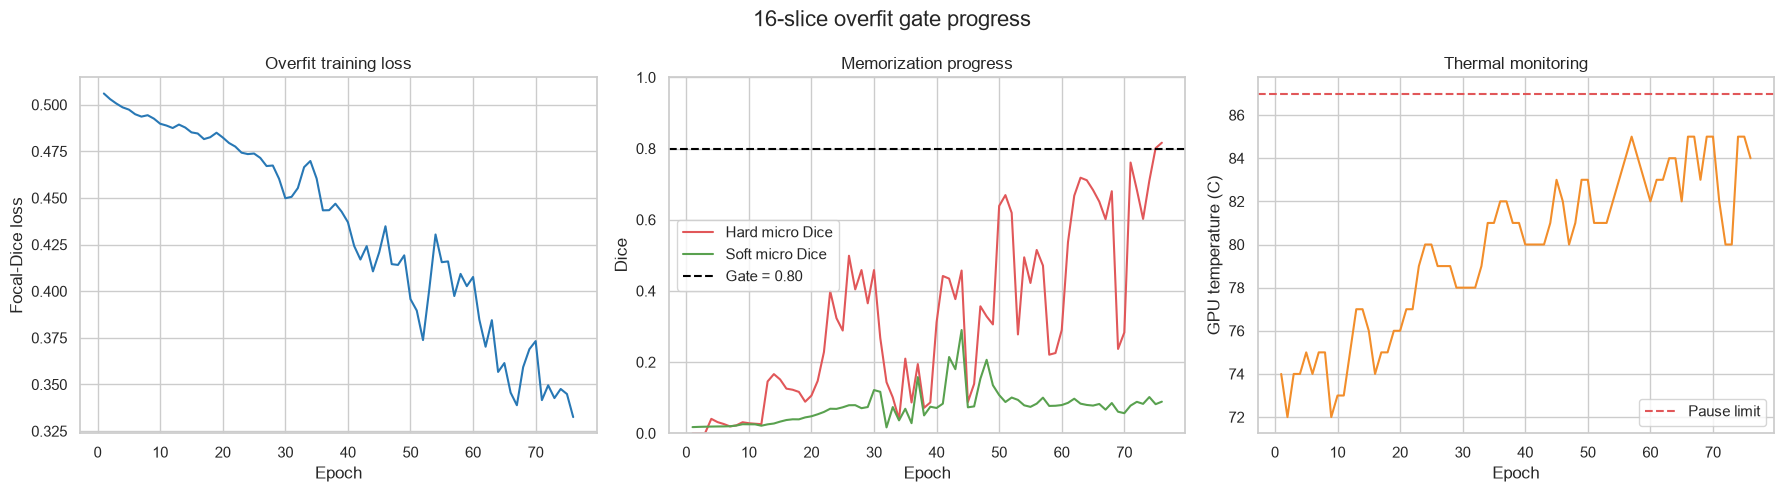

Saved: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\Practice\verified_loader_overfit_outputs\overfit_progress.png


In [12]:
history_path = OUTPUT_DIR / "overfit_history.csv"
if history_path.is_file() and history_path.stat().st_size > 0:
    history_frame = pd.read_csv(history_path)
else:
    history_frame = pd.DataFrame()

if history_frame.empty:
    print("No training history is available. Set RUN_OVERFIT=True and run the training cell.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(history_frame["epoch"], history_frame["loss"], color="#2878B5")
    axes[0].set_title("Overfit training loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Focal-Dice loss")

    axes[1].plot(
        history_frame["epoch"],
        history_frame["hard_micro_dice"],
        label="Hard micro Dice",
        color="#E15759",
    )
    axes[1].plot(
        history_frame["epoch"],
        history_frame["soft_micro_dice"],
        label="Soft micro Dice",
        color="#59A14F",
    )
    axes[1].axhline(GATE_DICE, color="black", linestyle="--", label="Gate = 0.80")
    axes[1].set_ylim(0, 1)
    axes[1].set_title("Memorization progress")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Dice")
    axes[1].legend()

    thermal_rows = history_frame.dropna(subset=["temperature_c"])
    if len(thermal_rows):
        axes[2].plot(
            thermal_rows["epoch"],
            thermal_rows["temperature_c"],
            color="#F28E2B",
        )
        axes[2].axhline(
            MAX_GPU_TEMP_C, color="#E15759", linestyle="--", label="Pause limit"
        )
        axes[2].set_ylabel("GPU temperature (C)")
        axes[2].legend()
    else:
        axes[2].text(
            0.5, 0.5, "GPU temperature unavailable", ha="center", va="center"
        )
    axes[2].set_title("Thermal monitoring")
    axes[2].set_xlabel("Epoch")

    fig.suptitle("16-slice overfit gate progress", fontsize=16)
    fig.tight_layout()
    progress_path = OUTPUT_DIR / "overfit_progress.png"
    fig.savefig(progress_path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Saved: {progress_path}")

### 10. Inspect predictions and error overlays

,sample_id,dice,predicted_pixels,true_pixels,mean_probability
7,v068_s0132,5.208333e-09,0,192,0.335570
6,v035_s0053,5.917160e-09,0,169,0.339353
3,v037_s0092,2.380952e-08,0,42,0.338203
2,v049_s0158,2.439024e-08,0,41,0.336241
1,v008_s0391,2.500000e-08,0,40,0.266785
0,v084_s0632,5.555555e-08,0,18,0.299168
10,v097_s0526,2.392857e-01,68,492,0.329355
5,v019_s0439,2.753129e-01,722,157,0.013088
4,v007_s0387,3.292978e-01,345,68,0.047930
11,v093_s0393,7.274291e-01,542,621,0.011105


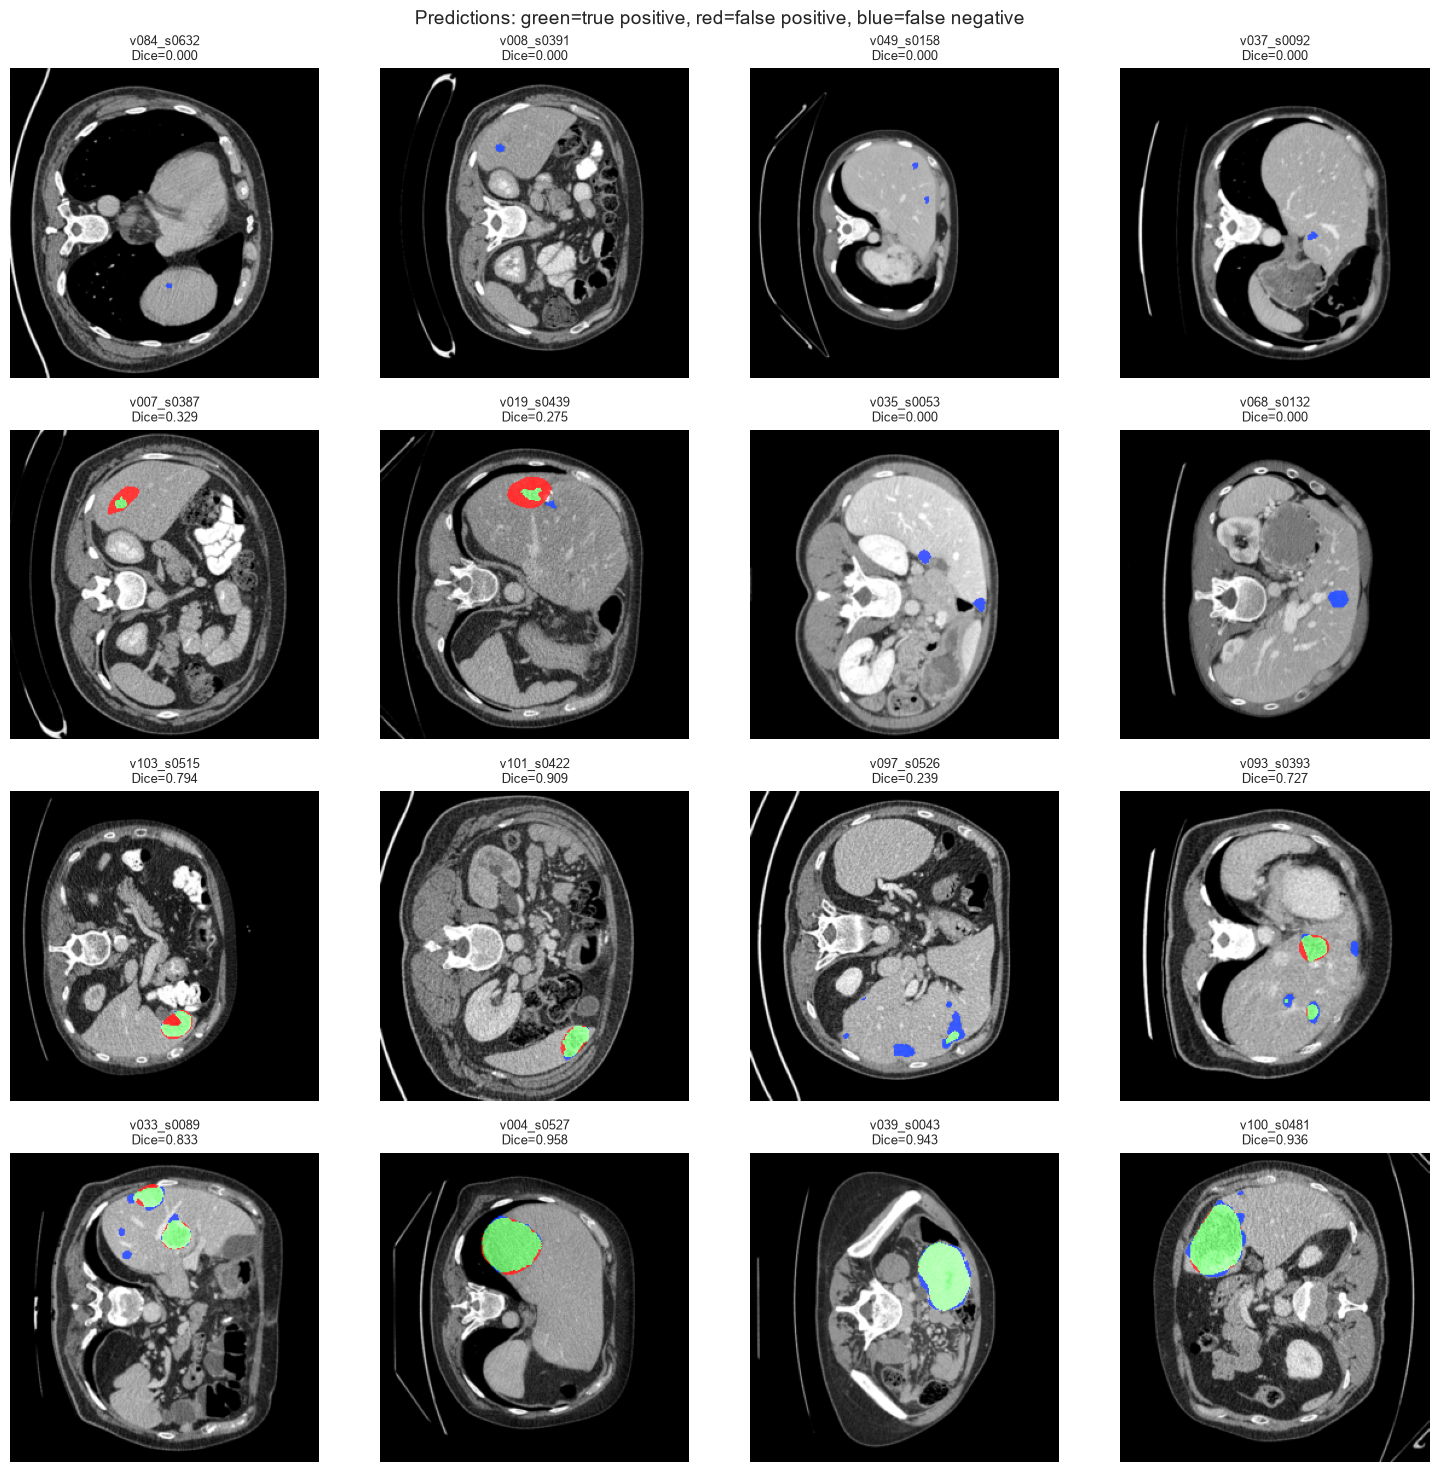

Saved: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\Practice\verified_loader_overfit_outputs\overfit_prediction_errors.png


In [13]:
if RUN_OVERFIT and "model" in globals() and "evaluation_loader" in globals():
    final_metrics = evaluate_overfit(
        model, evaluation_loader, device, PREDICTION_THRESHOLD
    )
    per_slice = pd.DataFrame(final_metrics["per_slice"]).sort_values("dice")
    per_slice.to_csv(OUTPUT_DIR / "overfit_per_slice.csv", index=False)
    display(per_slice)

    model.eval()
    prediction_records = {}
    with torch.inference_mode():
        for batch in evaluation_loader:
            probabilities = torch.sigmoid(
                model(batch["image"].to(device))
            ).cpu().numpy()
            for index, sample_id in enumerate(batch["sample_id"]):
                prediction_records[sample_id] = probabilities[index, 0]

    figure, axes = plt.subplots(4, 4, figsize=(15, 15))
    for axis, item in zip(axes.ravel(), overfit_dataset):
        sample_id = item["sample_id"]
        image = item["image"][0].numpy()
        truth = item["mask"][0].numpy().astype(bool)
        probability = prediction_records[sample_id]
        prediction = probability >= PREDICTION_THRESHOLD
        false_positive = prediction & ~truth
        false_negative = truth & ~prediction

        rgb = np.repeat(image[..., None], 3, axis=2)
        rgb[truth, 1] = np.clip(rgb[truth, 1] + 0.45, 0, 1)
        rgb[false_positive, 0] = 1.0
        rgb[false_positive, 1:] *= 0.35
        rgb[false_negative, 2] = 1.0
        rgb[false_negative, :2] *= 0.35
        dice = float(
            per_slice.loc[per_slice["sample_id"].eq(sample_id), "dice"].iloc[0]
        )
        axis.imshow(rgb)
        axis.set_title(f"{sample_id}\nDice={dice:.3f}", fontsize=9)
        axis.axis("off")

    figure.suptitle(
        "Predictions: green=true positive, red=false positive, blue=false negative",
        fontsize=14,
    )
    figure.tight_layout()
    prediction_path = OUTPUT_DIR / "overfit_prediction_errors.png"
    figure.savefig(prediction_path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Saved: {prediction_path}")
else:
    print("Prediction review is available after the overfit training cell runs.")

### 11. Produce the final gate decision

Passing authorizes **loader integration and a staged baseline run**, not test
evaluation or publication claims. A failure means the full baseline remains
blocked while the reason is diagnosed.

In [14]:
status_path = OUTPUT_DIR / "overfit_status.json"
status_payload = (
    json.loads(status_path.read_text(encoding="utf-8"))
    if status_path.is_file()
    else {"status": "not_run", "best_hard_micro_dice": None}
)
best_dice = status_payload.get("best_hard_micro_dice")

loader_gate_pass = bool(
    observed_manifest_hash == EXPECTED["manifest_sha256"]
    and len(train_dataset) == EXPECTED["split_slices"]["train"]
    and len(val_dataset) == EXPECTED["split_slices"]["val"]
    and audit_table["pixel_count_match"].all()
)
overfit_gate_pass = best_dice is not None and float(best_dice) >= GATE_DICE
all_gates_pass = loader_gate_pass and overfit_gate_pass

if all_gates_pass:
    decision = "PASS — proceed to manifest integration and staged baseline training."
    next_action = (
        "Wire VerifiedManifestDataset into the experiment builder, rerun the full "
        "test suite, then train the baseline to epoch 5 and validate only on val."
    )
elif status_payload.get("status") in {"interrupted", "paused_hot", "running"}:
    decision = "INCOMPLETE — resume the overfit gate; full baseline remains blocked."
    next_action = "Cool the GPU if needed and rerun the training cell."
else:
    decision = "FAIL — do not start full baseline or FAUP-Net training."
    next_action = (
        "Inspect the loss curve and prediction overlays. Check gradients/model "
        "output if loss is flat; inspect threshold and small-lesion behavior if "
        "soft Dice rises but hard Dice remains low."
    )

gate_result = {
    "dataset_build": DATASET_ROOT.name,
    "manifest_sha256": observed_manifest_hash,
    "loader_gate_pass": loader_gate_pass,
    "overfit_gate_pass": overfit_gate_pass,
    "all_gates_pass": all_gates_pass,
    "best_hard_micro_dice": best_dice,
    "required_hard_micro_dice": GATE_DICE,
    "overfit_status": status_payload.get("status"),
    "selected_training_slices": OVERFIT_SLICES,
    "test_images_accessed": False,
    "decision": decision,
    "next_action": next_action,
}
(OUTPUT_DIR / "gate_result.json").write_text(
    json.dumps(gate_result, indent=2), encoding="utf-8"
)
display(pd.DataFrame([gate_result]).T.rename(columns={0: "result"}))
print(decision)
print(next_action)

,result
dataset_build,build_corrected_20260713_214847_v2
manifest_sha256,575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63...
loader_gate_pass,True
overfit_gate_pass,True
all_gates_pass,True
best_hard_micro_dice,0.816306
required_hard_micro_dice,0.8
overfit_status,passed
selected_training_slices,16
test_images_accessed,False


PASS — proceed to manifest integration and staged baseline training.
Wire VerifiedManifestDataset into the experiment builder, rerun the full test suite, then train the baseline to epoch 5 and validate only on val.


## Next Steps

After the notebook finishes, share these small files from
`Practice/verified_loader_overfit_outputs/`:

- `gate_result.json`
- `overfit_status.json`
- `overfit_history.csv`
- `overfit_per_slice.csv`
- `loader_pixel_parity_audit.csv`
- `overfit_progress.png`
- `overfit_prediction_errors.png`

Do not share the checkpoint unless checkpoint-loading diagnosis is needed.

If the gate passes, the next implementation step is to route the experiment
builder to `VerifiedManifestDataset`, run the complete automated test suite, and
start the locked baseline with the staged 5→10 epoch protocol. If it fails, stop
architecture work and diagnose the loader, label pipeline, loss, gradients, and
prediction threshold using the saved evidence.